<a href="https://colab.research.google.com/github/bellakinch/TruthSeeker-News-Analysis-/blob/main/TruthSeeker_Unsupervised_Learning_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
   Unnamed: 0  majority_target  \
0           0             True   
1           1             True   
2           2             True   
3           3             True   
4           4             True   

                                           statement  BinaryNumTarget  \
0  End of eviction moratorium means millions of A...              1.0   
1  End of eviction moratorium means millions of A...              1.0   
2  End of eviction moratorium means millions of A...              1.0   
3  End of eviction moratorium means millions of A...              1.0   
4  End of eviction moratorium means millions of A...              1.0   

                                               tweet  followers_count  \
0  @POTUS Biden Blunders - 6 Month Update\n\nInfl...           4262.0   
1  @S0SickRick @Stairmaster_ @6d6f636869 Not as m...           1393.0   
2  THE SUPREME COURT is siding with super rich pr...              9.0   
3  @POTUS Biden Blunders\n\nBroken cam

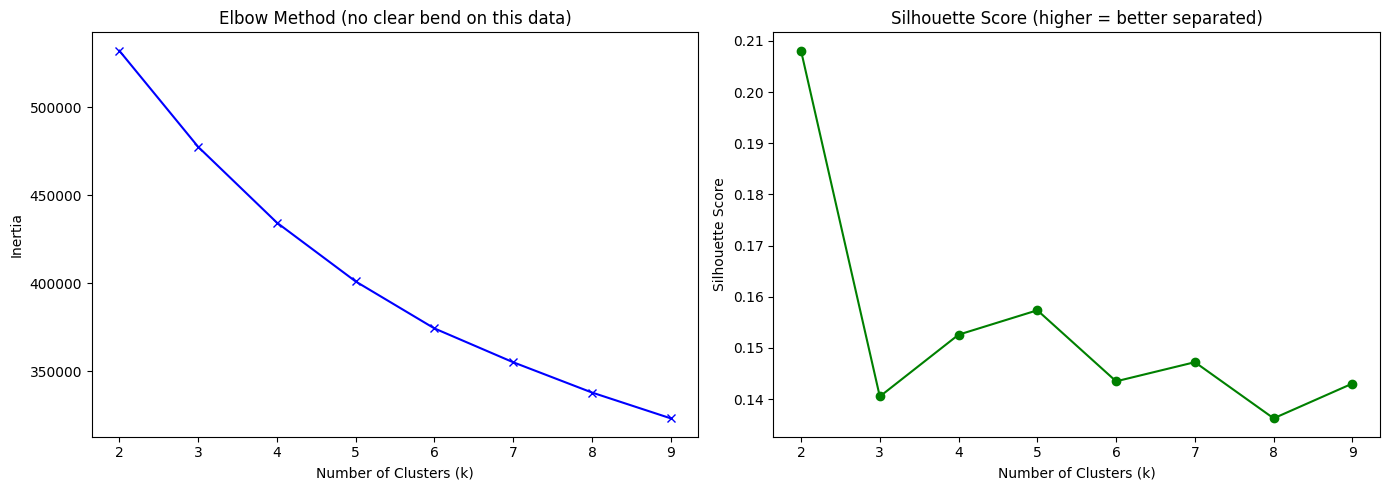

Silhouette scores by k:
  k=2: 0.2081
  k=3: 0.1405
  k=4: 0.1526
  k=5: 0.1574
  k=6: 0.1435
  k=7: 0.1472
  k=8: 0.1363
  k=9: 0.1431

Analysis for K-Means (K=2):

Cluster Analysis:
        BinaryNumTarget       
                   mean  count
Cluster                       
0                   0.0  20754
1                   0.0  44514


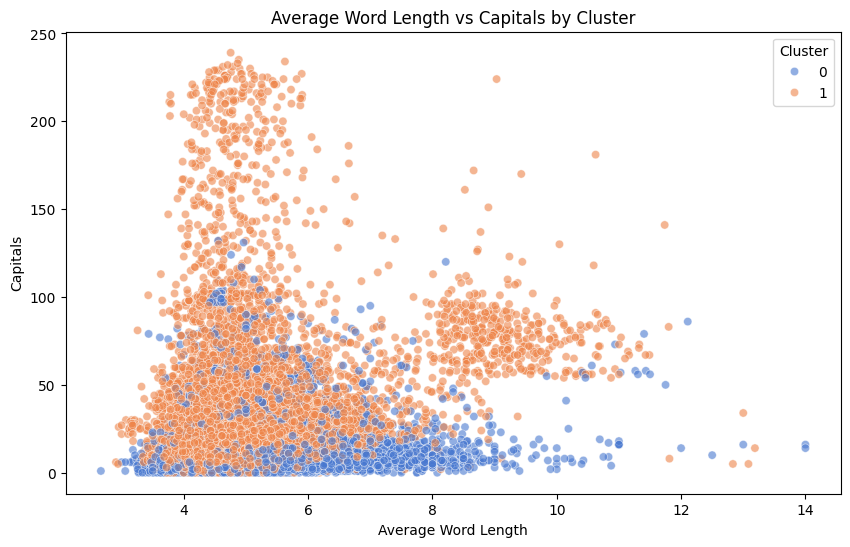


Average Linguistic Features by Cluster:
         Word count  Max word length  Min word length  Average word length  \
Cluster                                                                      
0         20.639925        11.790016         1.629710             5.133221   
1         43.446466        13.714719         1.245833             4.963970   

          capitals  past_verbs  exclamation  questions  long_word_freq  \
Cluster                                                                  
0         8.299460    0.967524     0.177508   0.231425        1.211718   
1        16.862335    2.447567     0.390214   0.394078        2.781305   

         short_word_freq  
Cluster                   
0              12.362388  
1              26.933864  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


#  --------------- Load data ----------------
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Features_For_Traditional_ML_Techniques (1).csv')
print(df.head())
print(df.shape)

# -------------- Clean up -----------------------
# Choosing features based on fake news linguistic structure
features = [
    "Word count",
    "Max word length",
    "Min word length",
    "Average word length",
    "capitals",
    "past_verbs",
    "exclamation",
    "questions",
    "long_word_freq",
    "short_word_freq"
]
print("\nSelected Linguistic Features:")
print(features)

# Remove observations missing selected linguistic feature
df_clean = df.dropna(
    subset=features + ["BinaryNumTarget"]
).copy()

print("\nRows After Removing Missing Values:")
print(len(df_clean))

# Now keep only only fake data based on hw instructions
df_clean = df_clean[
    df_clean["BinaryNumTarget"] == 0.0
].copy()

print("Number of Fake observations:", len(df_clean))

# Handle skewed features (the large values)
skewed_cols = [
    "Word count",
    "capitals",
    "past_verbs",
    "exclamation",
    "questions",
    "long_word_freq",
    "short_word_freq"
]

# Use log transformation so it can read
for col in skewed_cols:
    df_clean[col + "_log"] = np.log1p(df_clean[col])

# Create list of features that K-Means will use
features_log = [
    col + "_log" if col in skewed_cols else col
    for col in features
]

print("\nFeatures Used for K-Means:")
for feature in features_log:
    print(feature)

# Set my lingustic features as X
X = df_clean[features_log]

print("\nX Preview:")
print(X.head())

print("\nX Shape:")
print(X.shape)

# Stanadarize the features for equal influence on the clusters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nShape of Scaled Data:")
print(X_scaled.shape)

# ---------------- Elbow/ Silhouette models ------------------
# Find how many clusters to use with Elbow + Silhouette
inertia = []
sil_scores = []
k_range = range(2, 10)

# silhouette is O(n^2)-ish; score on a fixed random subsample for speed on 130k+ rows
rng = np.random.RandomState(0)
sample_idx = rng.choice(len(X_scaled), size=5000, replace=False) #randomly select 5000 rows

#For each candidate k, fit a fresh k-means model with that many clusters on the full scaled
#dataset. n_init=10 means it runs the whole k-means algorithm 10 times with different random
#starting points and keeps the best result.
#this protects against k-means getting unlucky and landing in a bad local solution.
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled[sample_idx], kmeans.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bx-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (no clear bend on this data)')

axes[1].plot(k_range, sil_scores, 'go-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better separated)')

plt.tight_layout()
plt.savefig("elbow_and_silhouette.png")
plt.show()

print("Silhouette scores by k:")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

# Based on elbow + silhouette (choose k and finalize model)
optimal_k = 2 # after
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nAnalysis for K-Means (K={optimal_k}):")

# Calculate average target (1=True, 0=False)
cluster_analysis = (df_clean.groupby("Cluster").agg({
        "BinaryNumTarget": ["mean","count"]}))
print("\nCluster Analysis:")
print(cluster_analysis)

# -------------- Visualization ---------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="Average word length",
    y="capitals",
    hue="Cluster",
    palette="muted",
    alpha=0.6
)

   # using word length and capitals (random bc 2 dimensional)
plt.xlabel("Average Word Length")
plt.ylabel( "Capitals")
plt.title("Average Word Length vs Capitals by Cluster")
plt.legend(title="Cluster")
plt.savefig("FinalCluster.png")
plt.show()

# ------ Average Linguistic Features by Cluster ----------
print("\nAverage Linguistic Features by Cluster:")
print(df_clean.groupby("Cluster")[features].mean())


There are present linguistic patterns that we can observe in data labeled as 'Fake'. After cleaning the dataset to only Fake observations, based on comparing the numbers, K Means identified two linguistic groups. One cluster consists mainly of shorter text and another consisting mainly of longer text with higher counts of linguistic features. With a low Silhouette Score (0.2081) can tell us that these patterns overlap and are not strongly separated.

Cluster 0 had 20,754 observations and generally contained shorter text, with an average of  21 words.
Cluster 1 had 44,514 observations and generally contained longer text, with an average of about 43 words. Cluster 1 also had more capital letters, past-tense verbs, exclamation marks, questions, and long and short words.



Cluster 1 had more capital letters, past-tense verbs, exclamation marks, and questions on average.
Cluster 1 also had higher frequencies of both long and short words.
Average word length was very similar between the clusters: 5.13 for Cluster 0 and 4.96 for Cluster 1 (This could suggest average word length doesn't have much impact say on being relevant to fake news classifying)
Overall, the biggest linguistic differences between the clusters appear to be word count, capitals, and short word frequency


---


Cluster 0 = generally shorter Fake text
20,754 observations

21 words on average

Fewer capitals (8.30)

Fewer past tense verbs, questions, and exclamation marks

Lower long and short word frequencies


---


Cluster 1 = generally longer Fake text

44,514 observations

43 words on average

More capitals (16.86)

More past tense verbs, questions, and exclamation marks

Higher long and short word frequencies

